In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
ROI_DATASET_ROOT = Path("../outputs/roi_dataset_v3")

GENUINE_DIR = ROI_DATASET_ROOT / "genuine"
FORGED_DIR = ROI_DATASET_ROOT / "forged"

MODEL_OUTPUT_DIR = Path("../outputs/models")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

In [3]:
records = []

for path in GENUINE_DIR.rglob("*.png"):
    records.append({
        "image_path": str(path),
        "label": 0,
        "class_name": "genuine"
    })

for path in FORGED_DIR.rglob("*.png"):
    records.append({
        "image_path": str(path),
        "label": 1,
        "class_name": "forged"
    })

df = pd.DataFrame(records)

print("Total clean ROI images:", len(df))
print(df["class_name"].value_counts())

df.head()

Total clean ROI images: 495
class_name
genuine    295
forged     200
Name: count, dtype: int64


,image_path,label,class_name
0,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
1,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
2,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
3,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
4,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts())

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train: 346
Validation: 74
Test: 75

Train distribution:
class_name
genuine    206
forged     140
Name: count, dtype: int64

Validation distribution:
class_name
genuine    44
forged     30
Name: count, dtype: int64

Test distribution:
class_name
genuine    45
forged     30
Name: count, dtype: int64


In [5]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = preprocess_input(image)

    return image, label

In [6]:
def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
])

In [8]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 163s 2us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.8398058252427184), 1: np.float64(1.2357142857142858)}


In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_OUTPUT_DIR / "stamp_resnet50_best.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5260 - loss: 0.7652 - precision: 0.4294 - recall: 0.5214 - val_accuracy: 0.6081 - val_loss: 0.6673 - val_precision: 0.6667 - val_recall: 0.0667
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5925 - loss: 0.7176 - precision: 0.4971 - recall: 0.6214 - val_accuracy: 0.6622 - val_loss: 0.6310 - val_precision: 0.7273 - val_recall: 0.2667
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5694 - loss: 0.7294 - precision: 0.4710 - recall: 0.5214 - val_accuracy: 0.6622 - val_loss: 0.6050 - val_precision: 0.7273 - val_recall: 0.2667
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6272 - loss: 0.6467 - precision: 0.5342 - recall: 0.6143 - val_accuracy: 0.6351 - val_loss: 0.5974 - val_precision: 0.8000 - val_recall: 0.1333
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6445 - loss: 0.6359 - precision: 0.5548 - recall: 0.6143 - val_accuracy: 0.7297 - val_loss: 0.5603 - val

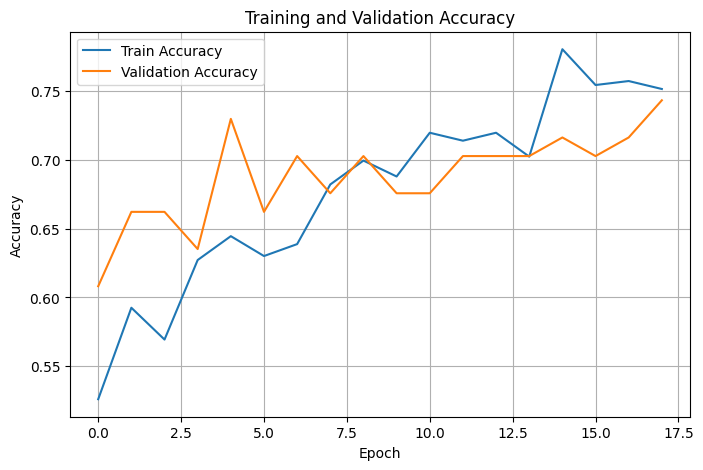

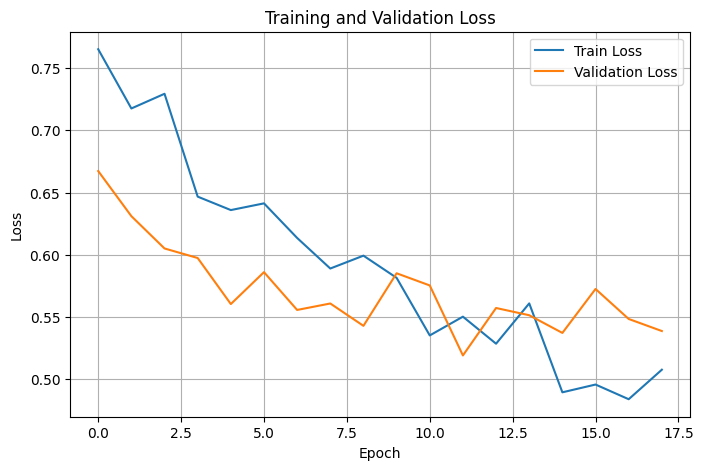

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
base_model.trainable = True

# Freeze lower layers, fine-tune only top part
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6908 - loss: 0.5528 - precision: 0.5912 - recall: 0.7643 - val_accuracy: 0.6757 - val_loss: 0.5920 - val_precision: 1.0000 - val_recall: 0.2000
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7543 - loss: 0.4862 - precision: 0.6708 - recall: 0.7714 - val_accuracy: 0.6757 - val_loss: 0.6191 - val_precision: 1.0000 - val_recall: 0.2000
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7919 - loss: 0.4604 - precision: 0.7179 - recall: 0.8000 - val_accuracy: 0.6892 - val_loss: 0.6237 - val_precision: 1.0000 - val_recall: 0.2333
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8179 - loss: 0.4391 - precision: 0.7516 - recall: 0.8214 - val_accuracy: 0.6892 - val_loss: 0.6824 - val_precision: 1.0000 - val_recall: 0.2333
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8382 - loss: 0.3997 - precision: 0.7917 - recall: 0.8143 - val_accuracy: 0.7027 - val_loss: 0.6794 - val

In [13]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-8)
print("Test F1-score:", f1_score)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 825ms/step - accuracy: 0.7333 - loss: 0.5656 - precision: 0.9167 - recall: 0.3667
Test Loss: 0.5656347870826721
Test Accuracy: 0.7333333492279053
Test Precision: 0.9166666865348816
Test Recall: 0.36666667461395264
Test F1-score: 0.5238095310811569


In [14]:
y_true = test_df["label"].values

y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["genuine", "forged"]
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step  
              precision    recall  f1-score   support

     genuine       0.70      0.98      0.81        45
      forged       0.92      0.37      0.52        30

    accuracy                           0.73        75
   macro avg       0.81      0.67      0.67        75
weighted avg       0.79      0.73      0.70        75



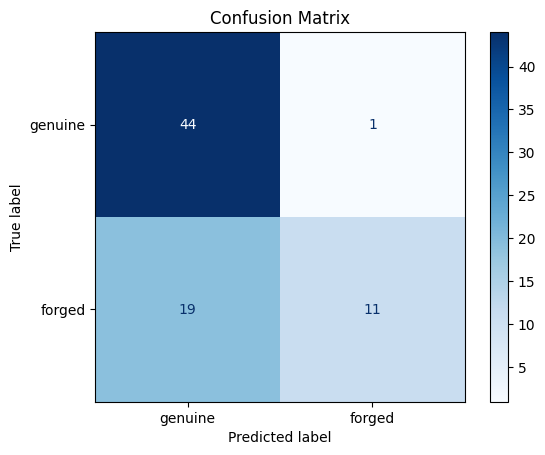

In [15]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["genuine", "forged"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [16]:
final_model_path = MODEL_OUTPUT_DIR / "stamp_resnet50_final.keras"

model.save(final_model_path)

print("Model saved to:")
print(final_model_path.resolve())

Model saved to:
H:\UOR\7th sem\Computer Vision\stamp-verification-project\outputs\models\stamp_resnet50_final.keras
